# Explaining Machine Learning Survival Models with Shapley Values

MSc Dissertation — MATH5872M, University of Leeds.

This notebook reproduces every figure and numerical result in the dissertation.
Both datasets load directly from package loaders, so no data files are needed.
The random seed is fixed at 42 throughout.

**Runtime:** roughly 30–40 minutes end to end. Part 6 dominates, since it computes
*exact* SurvSHAP(t) values by enumerating all 2⁹ = 512 coalitions for every patient
at every time point.

## Setup

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

from itertools import combinations
from math import factorial

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

import shap
import statsmodels.api as sm
from scipy import stats

from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

from sksurv.datasets import load_gbsg2
from sksurv.preprocessing import OneHotEncoder
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sksurv.metrics import integrated_brier_score
from sksurv.nonparametric import kaplan_meier_estimator
from survshap import SurvivalModelExplainer, PredictSurvSHAP


SEED = 42
PALETTE = ['#d73027', '#2166ac', '#1a9850', '#762a83', '#f46d43',
           '#4575b4', '#74add1', '#fdae61', '#a6d96a']
print('packages loaded')

packages loaded


---
# Part 1 — SHAP on the diabetes benchmark
*Dissertation Sections 5.1–5.2*

### Load the data and fit a Random Forest

In [2]:
feat_names = ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
X_raw, y = load_diabetes(return_X_y=True)
X = pd.DataFrame(X_raw, columns=feat_names)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=SEED)

rf = RandomForestRegressor(n_estimators=200, max_depth=6,
                           random_state=SEED).fit(X_tr, y_tr)
print(f"n = {len(X)} patients, p = {X.shape[1]} features")
print(f"Random Forest R2 = {r2_score(y_te, rf.predict(X_te)):.3f}")

n = 442 patients, p = 10 features
Random Forest R2 = 0.476


### TreeSHAP and the efficiency axiom

TreeSHAP is *exact* for tree ensembles. The efficiency axiom requires that the
attributions sum to the prediction minus the global mean:

$$\sum_i \phi_i = f(\mathbf{x}) - \mathbb{E}[f(\mathbf{X})]$$

In [3]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_te.values)
base = float(explainer.expected_value[0])

i = 5
pred = float(rf.predict(X_te.values[i:i + 1])[0])
total = base + shap_values[i].sum()
print(f"Efficiency check, patient {i}:")
print(f"  E[f(X)] = {base:.3f}")
print(f"  sum phi = {shap_values[i].sum():.3f}")
print(f"  sum     = {total:.3f}   f(x) = {pred:.3f}")
print(f"  holds   = {abs(total - pred) < 1e-6}")

imp = pd.Series(np.abs(shap_values).mean(0), index=feat_names)
print("\nGlobal importance (mean |phi|):")
print(imp.sort_values(ascending=False).round(3).to_string())

Efficiency check, patient 5:
  E[f(X)] = 154.353
  sum phi = -36.944
  sum     = 117.409   f(x) = 117.409
  holds   = True

Global importance (mean |phi|):
bmi    28.698
s5     20.764
bp     10.439
s3      4.586
age     3.546
s6      2.823
s4      2.701
s1      2.546
s2      1.752
sex     1.480


### Figure 5.1 — beeswarm

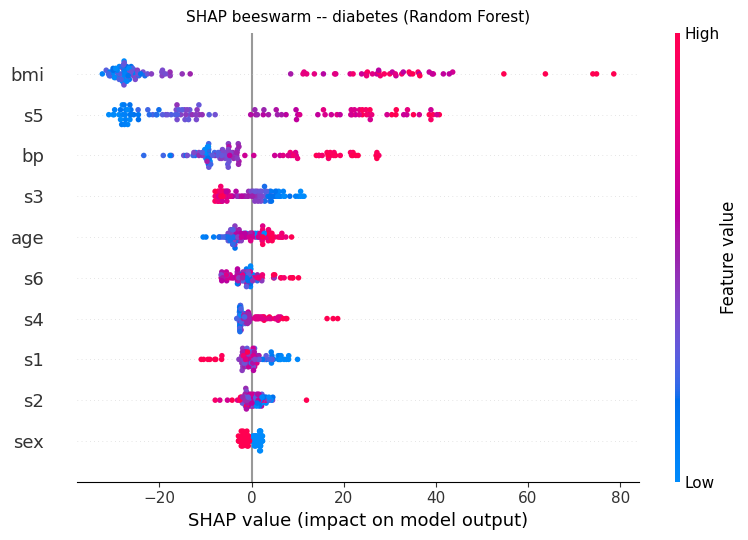

In [4]:
plt.figure(figsize=(8, 4.5))
shap.summary_plot(shap_values, X_te, feature_names=feat_names,
                  show=False, plot_type="dot", max_display=10)
plt.title("SHAP beeswarm -- diabetes (Random Forest)", fontsize=11, pad=8)
plt.tight_layout(); plt.savefig("c5_beeswarm.png", dpi=170, bbox_inches="tight")
plt.show()

### Figure 5.2 — waterfall for one patient

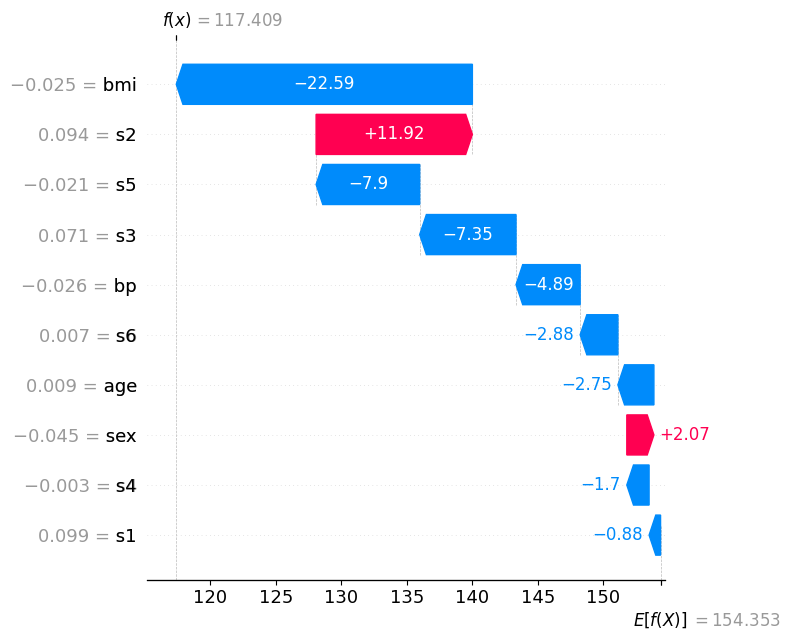

In [5]:
plt.figure(figsize=(8, 4))
shap.plots.waterfall(
    shap.Explanation(values=shap_values[i], base_values=base,
                     data=X_te.values[i], feature_names=feat_names), show=False)
plt.tight_layout(); plt.savefig("c5_waterfall.png", dpi=170, bbox_inches="tight")
plt.show()

---
# Part 2 — Linear model versus Random Forest
*Dissertation Section 5.3*

For a linear model the Shapley value is exactly $\phi_i = \beta_i(x_i - \bar{x}_i)$.
Comparing with the RF attributions exposes collinearity-driven misattribution.

In [6]:
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

lm = LinearRegression().fit(X_tr_s, y_tr)
print(f"Linear R2 = {r2_score(y_te, lm.predict(X_te_s)):.3f}")
print(f"RF     R2 = {r2_score(y_te, rf.predict(X_te)):.3f}")

lm_shap = shap.LinearExplainer(lm, X_tr_s).shap_values(X_te_s)
rf_shap = shap_values

comp = pd.DataFrame({
    "Linear mean|phi|": np.abs(lm_shap).mean(0).round(3),
    "RF mean|phi|":     np.abs(rf_shap).mean(0).round(3),
}, index=feat_names).sort_values("RF mean|phi|", ascending=False)
print()
print(comp.to_string())
print("\ns1: the linear model cannot separate it from s2-s4, which are")
print("correlated serum fractions, and over-attributes to it.")

Background dataset has 331 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=331 when initializing the masker.


Linear R2 = 0.485
RF     R2 = 0.476

     Linear mean|phi|  RF mean|phi|
bmi            22.439        28.698
s5             27.816        20.764
bp             15.558        10.439
s3              4.686         4.586
age             2.022         3.546
s6              1.025         2.823
s4             10.178         2.701
s1             33.010         2.546
s2             18.391         1.752
sex            11.440         1.480

s1: the linear model cannot separate it from s2-s4, which are
correlated serum fractions, and over-attributes to it.


### Figure 5.3 — attribution comparison

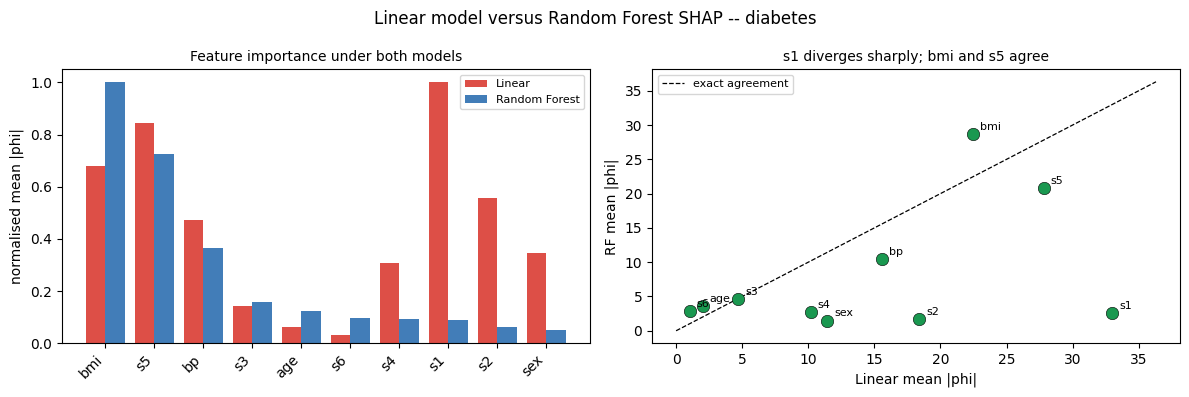

In [7]:
li, ri = np.abs(lm_shap).mean(0), np.abs(rf_shap).mean(0)
order = np.argsort(-ri)
x = np.arange(len(feat_names))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(x - .2, li[order] / li.max(), .4, label="Linear",
          color="#d73027", alpha=.85)
ax[0].bar(x + .2, ri[order] / ri.max(), .4, label="Random Forest",
          color="#2166ac", alpha=.85)
ax[0].set_xticks(x)
ax[0].set_xticklabels([feat_names[k] for k in order], rotation=45, ha="right")
ax[0].set_ylabel("normalised mean |phi|")
ax[0].set_title("Feature importance under both models", fontsize=10)
ax[0].legend(fontsize=8)

ax[1].scatter(li, ri, s=80, c="#1a9850", zorder=3, edgecolor="k", lw=.4)
for k, f in enumerate(feat_names):
    ax[1].annotate(f, (li[k], ri[k]), fontsize=8,
                   xytext=(5, 3), textcoords="offset points")
lim = max(li.max(), ri.max()) * 1.1
ax[1].plot([0, lim], [0, lim], "k--", lw=.9, label="exact agreement")
ax[1].set_xlabel("Linear mean |phi|")
ax[1].set_ylabel("RF mean |phi|")
ax[1].set_title("s1 diverges sharply; bmi and s5 agree", fontsize=10)
ax[1].legend(fontsize=8)

plt.suptitle("Linear model versus Random Forest SHAP -- diabetes", fontsize=12)
plt.tight_layout(); plt.savefig("c5_lmrf.png", dpi=170, bbox_inches="tight")
plt.show()

---
# Part 3 — Shapley regression (Joseph, 2019)
*Dissertation Section 5.4*

Regress the observed outcome on the SHAP values. If the model is calibrated the
coefficient should be **1**, not merely non-zero. Two tests per feature:
$H_0:\beta_k=0$ (predictive) and $H_0:\beta_k=1$ (correctly scaled).


PART 3 -- Shapley regression (Joseph 2019), scalar case
intercept = 155.46   R2 = 0.582

feature      beta      SE   p(b=0)   p(b=1)
-------------------------------------------
age        -0.289   1.365    0.832    0.347
sex         9.315   4.461    0.037    0.065
bmi         0.935   0.198    0.000    0.744
bp          0.386   0.549    0.483    0.266
s1         -2.278   1.946    0.242    0.095
s2          0.642   2.360    0.786    0.880
s3          2.073   2.139    0.332    0.617
s4         -0.983   2.082    0.637    0.343
s5          1.551   0.369    0.000    0.139
s6          3.611   1.447    0.013    0.074


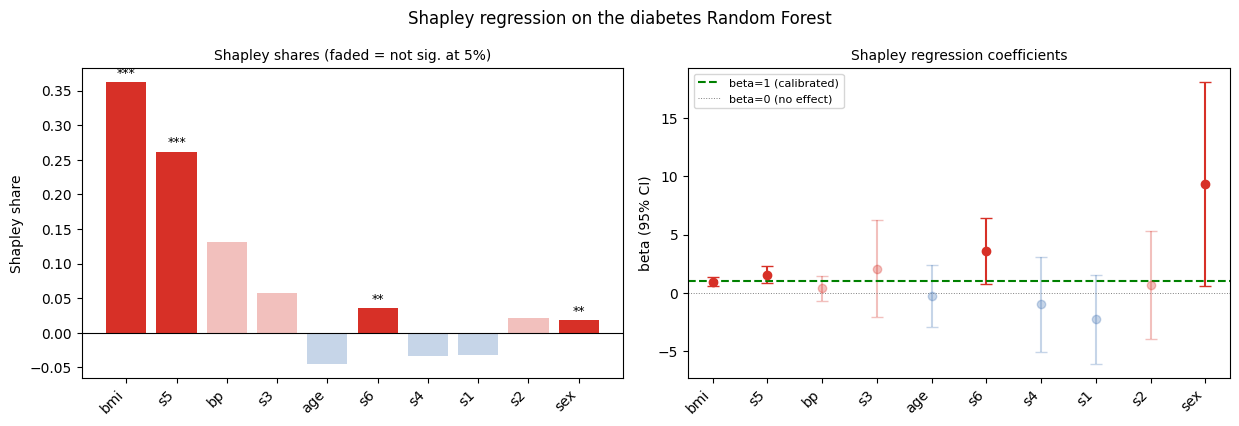

In [8]:
print("\n" + "=" * 70)
print("PART 3 -- Shapley regression (Joseph 2019), scalar case")
print("=" * 70)

ols = sm.OLS(y_te, sm.add_constant(shap_values)).fit(cov_type="HC3")
b, se, p0 = ols.params[1:], ols.bse[1:], ols.pvalues[1:]
# two-sided test of H0: beta = 1
p1 = np.array([2 * stats.t.sf(abs((b[k] - 1) / se[k]), df=ols.df_resid)
               for k in range(len(feat_names))])

print(f"intercept = {ols.params[0]:.2f}   R2 = {ols.rsquared:.3f}")
print(f"\n{'feature':8s}{'beta':>9}{'SE':>8}{'p(b=0)':>9}{'p(b=1)':>9}")
print("-" * 43)
for k, f in enumerate(feat_names):
    print(f"{f:8s}{b[k]:9.3f}{se[k]:8.3f}{p0[k]:9.3f}{p1[k]:9.3f}")

# Shapley shares: signed relative importance
ma = np.abs(shap_values).mean(0)
gamma = np.sign(b) * ma / ma.sum()
ci = ols.conf_int()
lo = np.array([ci[k + 1][0] for k in range(len(feat_names))])
hi = np.array([ci[k + 1][1] for k in range(len(feat_names))])

order = np.argsort(-np.abs(gamma))
cols = ["#d73027" if v > 0 else "#4575b4" for v in gamma[order]]
alphas = [1.0 if p < .05 else .3 for p in p0[order]]

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.3))
bars = ax[0].bar(range(len(feat_names)), gamma[order], color=cols)
for bar, al in zip(bars, alphas):
    bar.set_alpha(al)
for j, k in enumerate(order):
    star = ("***" if p0[k] < .01 else "**" if p0[k] < .05
            else "*" if p0[k] < .1 else "")
    if star:
        ax[0].text(j, gamma[k] + .004 * np.sign(gamma[k]), star,
                   ha="center", va="bottom" if gamma[k] > 0 else "top",
                   fontsize=9)
ax[0].axhline(0, color="k", lw=.8)
ax[0].set_xticks(range(len(feat_names)))
ax[0].set_xticklabels([feat_names[k] for k in order], rotation=45, ha="right")
ax[0].set_ylabel("Shapley share")
ax[0].set_title("Shapley shares (faded = not sig. at 5%)", fontsize=10)

for j, k in enumerate(order):
    ax[1].errorbar(j, b[k], yerr=[[b[k] - lo[k]], [hi[k] - b[k]]],
                   fmt="o", color=cols[j], capsize=4, alpha=alphas[j], ms=6)
ax[1].axhline(1, color="green", lw=1.5, ls="--", label="beta=1 (calibrated)")
ax[1].axhline(0, color="grey", lw=.7, ls=":", label="beta=0 (no effect)")
ax[1].set_xticks(range(len(feat_names)))
ax[1].set_xticklabels([feat_names[k] for k in order], rotation=45, ha="right")
ax[1].set_ylabel("beta (95% CI)")
ax[1].legend(fontsize=8)
ax[1].set_title("Shapley regression coefficients", fontsize=10)

plt.suptitle("Shapley regression on the diabetes Random Forest", fontsize=12)
plt.tight_layout()
plt.savefig("c5_shapreg.png", dpi=170, bbox_inches="tight")
plt.show()



# ============================================================================
# PART 4 -- Survival models: fitting and evaluation   [Chapter 6.1]
# ============================================================================

---
# Part 4 — Survival models on GBSG
*Dissertation Section 6.1*


PART 4 -- Survival model fitting (GBSG)
n = 686   events = 299 (43.6%)   censored = 387 (56.4%)



model    C-index     IBS
------------------------
RSF        0.667   0.171
Cox        0.644   0.175
GBM        0.641   0.177


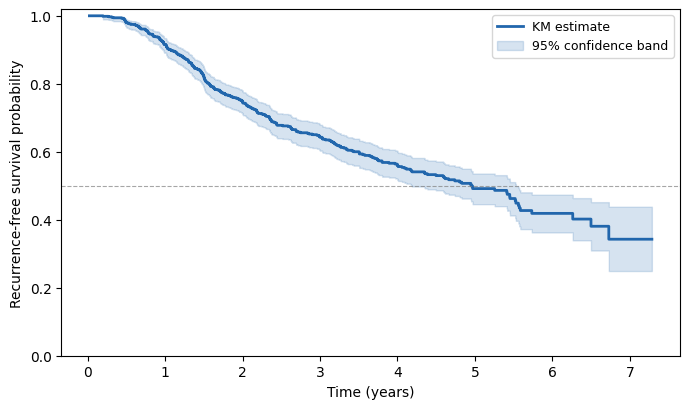

In [9]:
print("\n" + "=" * 70)
print("PART 4 -- Survival model fitting (GBSG)")
print("=" * 70)

X_raw, y = load_gbsg2()
Xe = OneHotEncoder().fit_transform(X_raw)
feats = list(Xe.columns)

n_ev = y["cens"].sum()
print(f"n = {len(y)}   events = {n_ev} ({100*n_ev/len(y):.1f}%)   "
      f"censored = {len(y)-n_ev} ({100*(len(y)-n_ev)/len(y):.1f}%)")

X_tr, X_te, y_tr, y_te = train_test_split(
    Xe, y, test_size=0.25, random_state=SEED)

cox = CoxPHSurvivalAnalysis(alpha=0.1).fit(X_tr, y_tr)
rsf = RandomSurvivalForest(n_estimators=100, min_samples_split=10,
                           min_samples_leaf=5, random_state=SEED,
                           n_jobs=-1).fit(X_tr, y_tr)
# The GBM answers a narrower question than it might appear to: whether the
# importance reversal depends on the RSF's particular use of trees.  RSF
# averages Nelson-Aalen estimates over bootstrapped trees split on the
# log-rank statistic; GBM fits an additive expansion to the Cox partial
# likelihood gradient.  Agreement rules out log-rank splitting and bagging
# as explanations.  It does NOT rule out the bias both share -- tree methods
# favour continuous covariates over binary ones -- so agreement here is not
# evidence that the reversal is real.  That comes from Sauerbrei et al.
# (1999), a fractional polynomial analysis of the same cohort with no
# splitting mechanism at all.  See Section 6.3.2 of the dissertation.
gbm = GradientBoostingSurvivalAnalysis(n_estimators=200, learning_rate=0.05,
                                       max_depth=3,
                                       random_state=SEED).fit(X_tr, y_tr)

fns = {"RSF": rsf.predict_survival_function(X_te),
       "GBM": gbm.predict_survival_function(X_te),
       "Cox": cox.predict_survival_function(X_te)}
ev_times = fns["RSF"][0].x[5:-5]

print(f"\n{'model':6s}{'C-index':>10}{'IBS':>8}")
print("-" * 24)
for name, model in [("RSF", rsf), ("Cox", cox), ("GBM", gbm)]:
    arr = np.row_stack([f(ev_times) for f in fns[name]])
    ibs = integrated_brier_score(y_tr, y_te, arr, ev_times)
    print(f"{name:6s}{model.score(X_te, y_te):10.3f}{ibs:8.3f}")

# Kaplan-Meier for the full cohort (Figure 4.1)
t_km, s_km, conf = kaplan_meier_estimator(y["cens"], y["time"],
                                          conf_type="log-log")
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.step(t_km / 365, s_km, where="post", color="#2166ac", lw=2,
        label="KM estimate")
ax.fill_between(t_km / 365, conf[0], conf[1], step="post", alpha=.18,
                color="#2166ac", label="95% confidence band")
ax.axhline(.5, color="grey", lw=.8, ls="--", alpha=.7)
ax.set_xlabel("Time (years)")
ax.set_ylabel("Recurrence-free survival probability")
ax.set_ylim(0, 1.02)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("fig_km_gbsg.png", dpi=180, bbox_inches="tight")
plt.show()





# ============================================================================
# PART 5 -- SurvSHAP(t): curves, ratio diagnostic, importance  [Ch 6.2-6.3]
# ============================================================================

---
# Part 5 — SurvSHAP(t)
*Dissertation Sections 6.2–6.3*

### Helper, and attribution curves for one patient

In [10]:
def survshap_one(model, X_tr, y_tr, X_te, idx, times):
    """Kernel SurvSHAP(t) for a single patient."""
    ex = SurvivalModelExplainer(model=model, data=X_tr, y=y_tr)
    ps = PredictSurvSHAP(calculation_method="kernel", random_state=SEED)
    ps.fit(ex, new_observation=X_te.iloc[[idx]], timestamps=times)
    return ps.result

times = fns["RSF"][0].x[5:-5:20]
d_rsf = survshap_one(rsf, X_tr, y_tr, X_te, 0, times)
d_cox = survshap_one(cox, X_tr, y_tr, X_te, 0, times)

t_cols = [c for c in d_cox.columns if c.startswith("t = ")]
t_yrs = np.array([float(c.split("= ")[1]) / 365 for c in t_cols])
print(f"{len(t_cols)} time points from {t_yrs[0]:.2f} to {t_yrs[-1]:.2f} years")

22 time points from 0.12 to 5.96 years


### Figure 6.1 — SurvSHAP(t) attribution curves

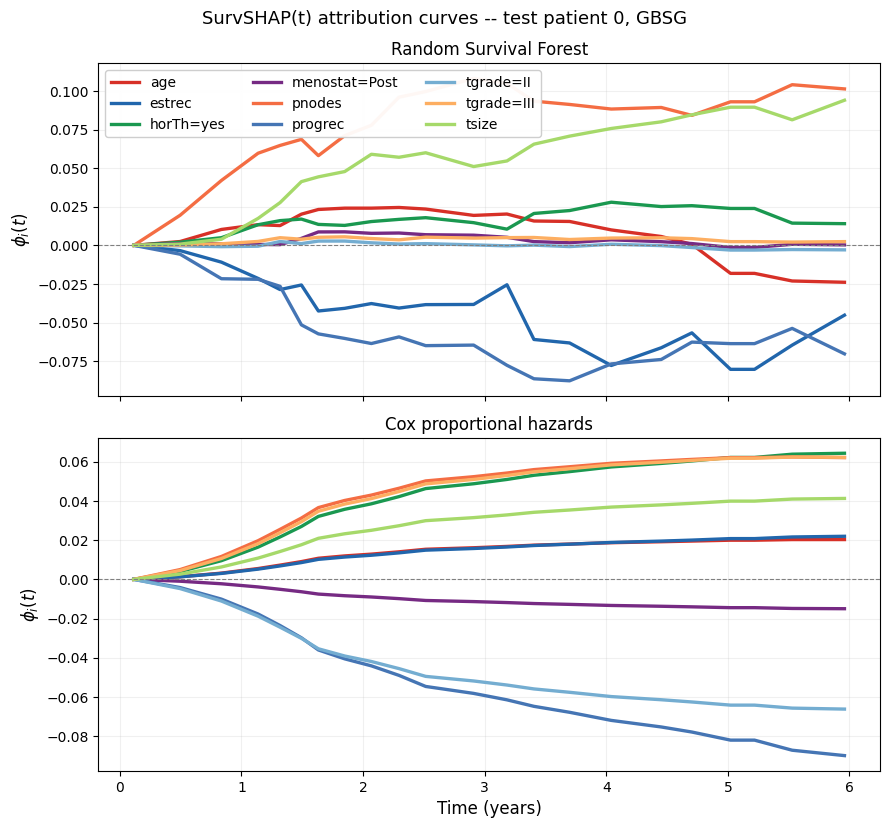

In [11]:
fig, ax = plt.subplots(2, 1, figsize=(9, 8.4), sharex=True)
for a, (d, title) in zip(ax, [(d_rsf, "Random Survival Forest"),
                              (d_cox, "Cox proportional hazards")]):
    for j, (_, row) in enumerate(d.iterrows()):
        a.plot(t_yrs, row[t_cols].values.astype(float),
               color=PALETTE[j % 9], lw=2.4, label=row["variable_name"])
    a.axhline(0, color="grey", lw=.8, ls="--")
    a.set_ylabel(r"$\phi_i(t)$", fontsize=12)
    a.set_title(title, fontsize=12, pad=6); a.grid(alpha=.18)
ax[1].set_xlabel("Time (years)", fontsize=12)
ax[0].legend(fontsize=10, ncol=3, loc="upper left", framealpha=.95)
plt.suptitle("SurvSHAP(t) attribution curves -- test patient 0, GBSG", fontsize=13)
plt.tight_layout(); plt.savefig("f_curves.png", dpi=190, bbox_inches="tight")
plt.show()

### Figure 6.2 — the proportionality diagnostic

Conjecture 3.1(i): if $\phi_i(t) \approx c(t)\beta_i(x_i-\bar{x}_i)$ with $c(t)$
shared across features, the ratio $\phi_i(t)/\phi_j(t)$ is **constant in $t$**,
because $c(t)$ cancels.

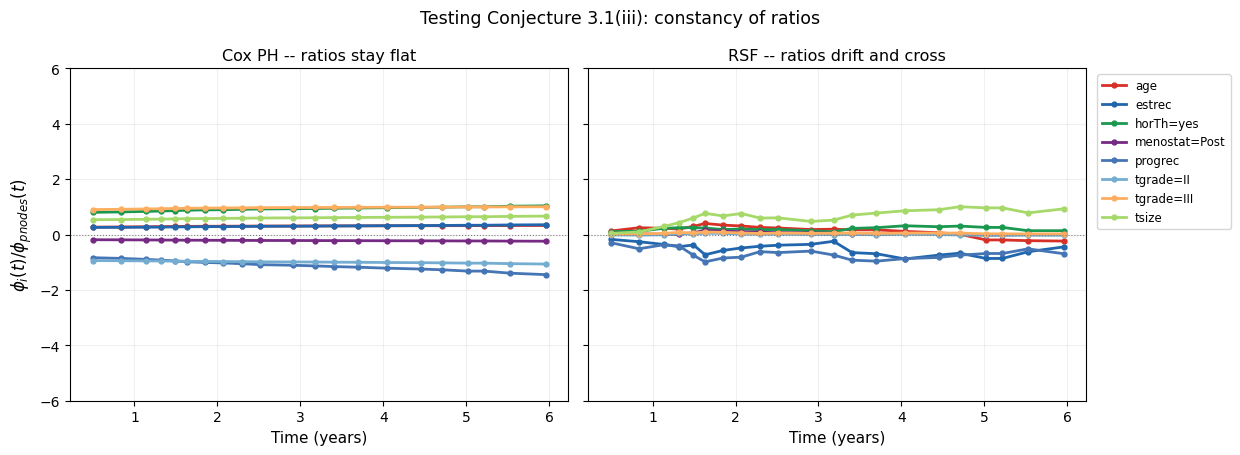

Median coefficient of variation of the ratios:
  Cox = 0.065   RSF = 0.416   (factor 6.4)


In [12]:
ref = "pnodes"
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.6), sharey=True)
cvs = {}
for a, (d, title, key) in zip(ax, [(d_cox, "Cox PH -- ratios stay flat", "Cox"),
                                   (d_rsf, "RSF -- ratios drift and cross", "RSF")]):
    den = d[d["variable_name"] == ref][t_cols].values.flatten().astype(float)
    mask = np.abs(den) > 0.004
    spreads = []
    for j, (_, row) in enumerate(d.iterrows()):
        if row["variable_name"] == ref: continue
        ratio = (row[t_cols].values.astype(float) / den)[mask]
        spreads.append(np.nanstd(ratio) / (abs(np.nanmean(ratio)) + 1e-9))
        a.plot(t_yrs[mask], ratio, "o-", color=PALETTE[j % 9],
               lw=2, ms=3.5, label=row["variable_name"])
    cvs[key] = np.nanmedian(spreads)
    a.axhline(0, color="grey", lw=.8, ls=":")
    a.set_xlabel("Time (years)", fontsize=11)
    a.set_title(title, fontsize=11.5); a.grid(alpha=.18); a.set_ylim(-6, 6)
ax[0].set_ylabel(r"$\phi_i(t)/\phi_{pnodes}(t)$", fontsize=12)
ax[1].legend(fontsize=8.5, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.suptitle("Testing Conjecture 3.1(iii): constancy of ratios", fontsize=12.5)
plt.tight_layout(); plt.savefig("f_ratio.png", dpi=190, bbox_inches="tight")
plt.show()

print(f"Median coefficient of variation of the ratios:")
print(f"  Cox = {cvs['Cox']:.3f}   RSF = {cvs['RSF']:.3f}   "
      f"(factor {cvs['RSF']/cvs['Cox']:.1f})")

### The feature importance reversal

The GBM tests whether the reversal depends on the RSF's *particular* use of trees.
It does not — but both are tree ensembles sharing a bias toward continuous
covariates, so their agreement is **not** evidence the reversal is real. That comes
from Sauerbrei et al. (1999).

In [13]:
def mean_importance(model, n=5):
    acc = []
    for i in range(n):
        d = survshap_one(model, X_tr, y_tr, X_te, i, times)
        tc = [c for c in d.columns if c.startswith("t = ")]
        d = d.copy(); d["imp"] = d[tc].abs().mean(axis=1)
        acc.append(d.set_index("variable_name")["imp"])
    return pd.concat(acc, axis=1).mean(axis=1)

rsf_imp = mean_importance(rsf)
gbm_imp = mean_importance(gbm)
cox_coef = pd.Series(cox.coef_, index=feats).abs()

tab = pd.DataFrame({"Cox |beta|": cox_coef.round(3),
                    "RSF mean|phi|": rsf_imp.round(4),
                    "GBM mean|phi|": gbm_imp.round(4)})
print("Feature importance -- the reversal:")
print(tab.sort_values("Cox |beta|", ascending=False).to_string())

Feature importance -- the reversal:
               Cox |beta|  RSF mean|phi|  GBM mean|phi|
tgrade=III          0.775         0.0034         0.0014
tgrade=II           0.619         0.0029         0.0000
horTh=yes           0.296         0.0189         0.0188
menostat=Post       0.111         0.0042         0.0004
pnodes              0.048         0.0650         0.0757
age                 0.015         0.0201         0.0157
tsize               0.006         0.0175         0.0342
progrec             0.003         0.0691         0.0756
estrec              0.001         0.0365         0.0174


### Figure 6.3 — three-way importance comparison

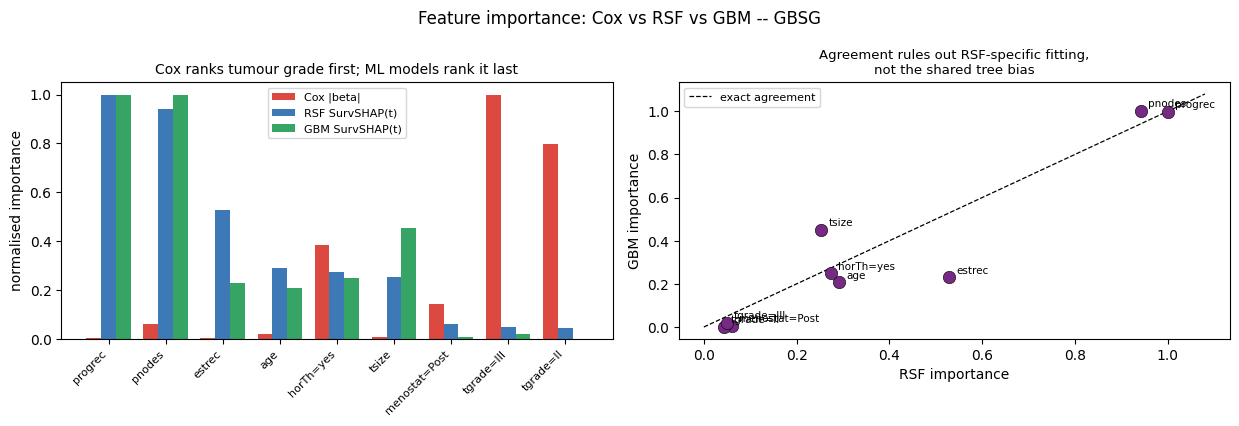

In [14]:
common = [f for f in feats if f in rsf_imp.index and f in gbm_imp.index]
norm = lambda s: s[common].values / s[common].values.max()
cn, rn, gn = norm(cox_coef), norm(rsf_imp), norm(gbm_imp)
order = np.argsort(-rn); x = np.arange(len(common))

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.3))
ax[0].bar(x - .26, cn[order], .26, label="Cox |beta|", color="#d73027", alpha=.88)
ax[0].bar(x, rn[order], .26, label="RSF SurvSHAP(t)", color="#2166ac", alpha=.88)
ax[0].bar(x + .26, gn[order], .26, label="GBM SurvSHAP(t)", color="#1a9850", alpha=.88)
ax[0].set_xticks(x)
ax[0].set_xticklabels([common[k] for k in order], rotation=45, ha="right", fontsize=8)
ax[0].set_ylabel("normalised importance"); ax[0].legend(fontsize=8)
ax[0].set_title("Cox ranks tumour grade first; ML models rank it last", fontsize=10)

ax[1].scatter(rn, gn, s=80, c="#762a83", zorder=3, edgecolor="k", lw=.4)
for k, f in enumerate(common):
    ax[1].annotate(f, (rn[k], gn[k]), fontsize=7.5,
                   xytext=(5, 3), textcoords="offset points")
ax[1].plot([0, 1.08], [0, 1.08], "k--", lw=.9, label="exact agreement")
ax[1].set_xlabel("RSF importance"); ax[1].set_ylabel("GBM importance")
ax[1].set_title("Agreement rules out RSF-specific fitting,\nnot the shared tree bias",
                fontsize=9.5)
ax[1].legend(fontsize=8)
plt.suptitle("Feature importance: Cox vs RSF vs GBM -- GBSG", fontsize=12)
plt.tight_layout(); plt.savefig("f_import.png", dpi=170, bbox_inches="tight")
plt.show()

---
# Part 6 — Shapley regression at each time point
*Dissertation Section 6.4*

Two facts give $\beta_k(t)=1$ in population:

1. **efficiency** — $\sum_k \phi_k(t|x) = S(t|x) - \mathbb{E}[S(t|X)]$
2. **the bridge** — $\mathbb{E}[\mathbf{1}\{T>t\}\,|\,x] = P(T>t|x) = S(t|x)$

Neither uses the Cox linear predictor, so the result is model-agnostic.

> **Note.** The response must be the *observed* outcome. Regressing the model's own
> $S(t|x)$ on its own $\phi_k(t)$ is an algebraic identity returning $\beta\equiv1$
> for *any* model, including a deliberately poor one.

### Exact SurvSHAP(t) by coalition enumeration
Feasible here because $p=9$ gives only 512 subsets, so efficiency holds to machine
precision and no approximation error contaminates the inference.

In [15]:
beta = cox.coef_
X_tr_np = X_tr.values
p = len(beta)

# Recover the baseline cumulative hazard from any fitted prediction:
#   H(t|x) = H0(t) * exp(beta'x)   =>   H0(t) = H(t|x0) / exp(beta'x0)
fn0 = cox.predict_cumulative_hazard_function(X_tr.iloc[[0]])[0]
eta0 = float(X_tr_np[0] @ beta)
H0 = lambda t: float(fn0(t)) / np.exp(eta0)
S_of = lambda M, h: np.exp(-h * np.exp(M @ beta))

rng = np.random.RandomState(0)
BG = X_tr_np[rng.choice(len(X_tr_np), 80, replace=False)]

all_subsets = [S for r in range(p + 1) for S in combinations(range(p), r)]
weights = {
    k: [(tuple(sorted(S + (k,))), tuple(sorted(S)),
         factorial(len(S)) * factorial(p - len(S) - 1) / factorial(p))
        for r in range(p)
        for S in combinations([j for j in range(p) if j != k], r)]
    for k in range(p)
}

def phi_fn(x, t):
    """Exact interventional SurvSHAP(t) by enumerating all 2^p coalitions."""
    h = H0(t)
    v = {}
    for S in all_subsets:
        M = BG.copy()
        if S:
            M[:, list(S)] = x[list(S)]
        v[S] = S_of(M, h).mean()
    return np.array([sum(w * (v[a] - v[b]) for a, b, w in weights[k])
                     for k in range(p)])

print(f"exact SurvSHAP ready: {len(all_subsets)} coalitions, {p} features")

exact SurvSHAP ready: 512 coalitions, 9 features


### Fit the regression at each time point

In [16]:
X_te_np = X_te.values
T = np.asarray(y_te["time"]); E = np.asarray(y_te["cens"])
N, p = len(T), len(feats)
t_grid = np.percentile(T, [10, 20, 30, 40, 50, 60, 70, 80, 90])

B = np.zeros((len(t_grid), p)); SE = np.zeros((len(t_grid), p))
for m, t in enumerate(t_grid):
    PHI = np.array([phi_fn(X_te_np[i], t) for i in range(N)])
    ols = sm.OLS((T > t).astype(float), sm.add_constant(PHI)).fit(cov_type="HC3")
    B[m], SE[m] = ols.params[1:], ols.bse[1:]
    print(f"  t = {t:6.0f} d   fitted")

tg, Gs = kaplan_meier_estimator(~E, T)
G = lambda t: Gs[max(np.searchsorted(tg, t, side="right") - 1, 0)]
Gt = np.array([G(t) for t in t_grid])

mean_se = SE.mean(0); dev = np.abs(B - 1).mean(0)
order = np.argsort(mean_se); well, poorly = order[:4], order[4:]

summary = pd.DataFrame({
    "Cox beta": pd.Series(cox.coef_, index=feats).round(3),
    "mean SE": pd.Series(mean_se, index=feats).round(3),
    "mean beta_k": pd.Series(B.mean(0), index=feats).round(3),
}).sort_values("mean SE")
print()
print(summary.to_string())
print(f"\ncorr(log SE, |beta-1|) = {np.corrcoef(np.log(mean_se), dev)[0,1]:.3f}")

  t =    348 d   fitted


  t =    525 d   fitted


  t =    713 d   fitted


  t =    861 d   fitted


  t =   1090 d   fitted


  t =   1282 d   fitted


  t =   1556 d   fitted


  t =   1754 d   fitted


  t =   2010 d   fitted

               Cox beta  mean SE  mean beta_k
progrec          -0.003    0.576       -0.153
tgrade=III        0.775    0.948        1.358
tgrade=II         0.619    1.003        0.984
pnodes            0.048    1.019        1.001
horTh=yes        -0.296    1.357        1.328
estrec            0.001    1.601       -2.612
age              -0.015    1.975       -1.325
tsize             0.006    2.646        2.232
menostat=Post     0.111    5.312        2.198

corr(log SE, |beta-1|) = 0.590


### Figure 6.4 — $\hat{\beta}_k(t)$ split by identification

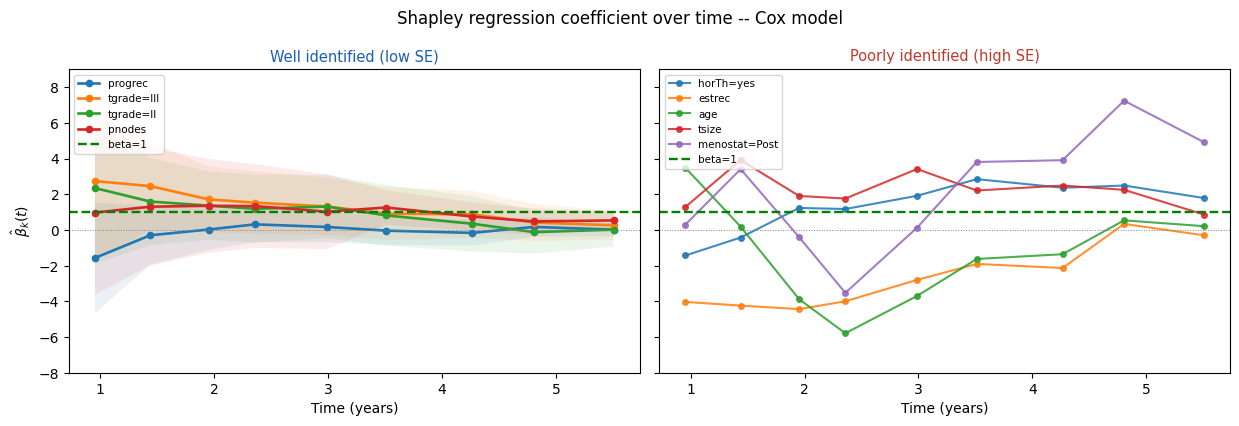

In [17]:
t_yrs2 = t_grid / 365
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.3), sharey=True)
for k in well:
    ax[0].plot(t_yrs2, B[:, k], "o-", lw=1.9, ms=4.5, label=feats[k])
    ax[0].fill_between(t_yrs2, B[:, k] - 1.96*SE[:, k], B[:, k] + 1.96*SE[:, k], alpha=.09)
for k in poorly:
    ax[1].plot(t_yrs2, B[:, k], "o-", lw=1.5, ms=4, alpha=.85, label=feats[k])
for a, title, colour in [(ax[0], "Well identified (low SE)", "#1a5fb4"),
                         (ax[1], "Poorly identified (high SE)", "#c0392b")]:
    a.axhline(1, color="green", lw=1.7, ls="--", label="beta=1")
    a.axhline(0, color="grey", lw=.7, ls=":")
    a.set_xlabel("Time (years)"); a.set_title(title, fontsize=10.5, color=colour)
    a.legend(fontsize=7.5, loc="upper left")
ax[0].set_ylabel(r"$\hat\beta_k(t)$"); ax[0].set_ylim(-8, 9)
plt.suptitle("Shapley regression coefficient over time -- Cox model", fontsize=12)
plt.tight_layout(); plt.savefig("f_shapreg.png", dpi=170, bbox_inches="tight")
plt.show()

### Figure 6.5 — censoring attenuates $\beta$ to $G(t)$

Ignoring censoring, $\mathbb{E}[\mathbf{1}\{\min(T,C)>t\}|x] = S(t|x)G(t)$, so
$\beta_k(t) = G(t)$ rather than 1.

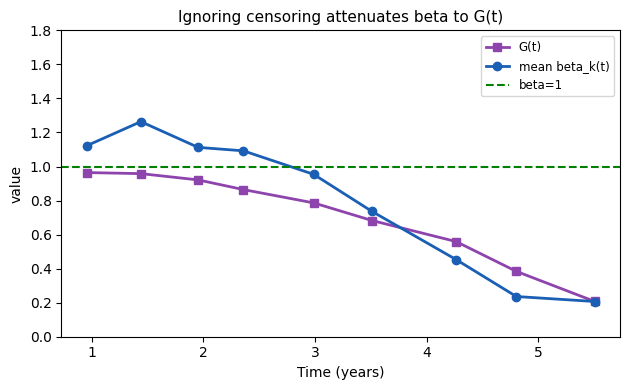

Last time point:  G = 0.207,  mean beta = 0.207


In [18]:
mb = B[:, well].mean(1)
fig, ax = plt.subplots(figsize=(6.4, 4))
ax.plot(t_yrs2, Gt, "s-", color="#8e44ad", lw=2, ms=6, label="G(t)")
ax.plot(t_yrs2, mb, "o-", color="#1a5fb4", lw=2, ms=6, label="mean beta_k(t)")
ax.axhline(1, color="green", lw=1.5, ls="--", label="beta=1")
ax.set_xlabel("Time (years)"); ax.set_ylabel("value"); ax.set_ylim(0, 1.8)
ax.set_title("Ignoring censoring attenuates beta to G(t)", fontsize=11)
ax.legend(fontsize=8.5)
plt.tight_layout(); plt.savefig("f_cens.png", dpi=170, bbox_inches="tight")
plt.show()

print(f"Last time point:  G = {Gt[-1]:.3f},  mean beta = {mb[-1]:.3f}")

---
### The misspecification diagnostic

`progrec` has the **smallest** standard error of any feature yet a coefficient
furthest from 1. Well identified, so not noise — this flags the Cox misspecification
using only the Cox fit, with no reference to any ML model.

> small SE **and** $\hat\beta_k$ far from 1 ⟹ covariate $k$ is misspecified